In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
np.random.seed(42)
X = 2 * np.random.rand(100,1)
y = 4 + 3*X + 2 * X**2 + np.random.randn(100,1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(X[:5])

[[0.74908024]
 [1.90142861]
 [1.46398788]
 [1.19731697]
 [0.31203728]]


In [ ]:
class PolynomialRegression:
    def __init__(self, degree):
        self.degree = degree
    def _polynomial_features(self, X):
        X_poly = np.ones((X.shape[0], 1))
        for d in range(1, self.degree + 1):
            X_poly = np.hstack((X_poly, X**d))
        return X_poly 
    def fit(self, X, Y):
        X_poly = self._polynomial_features(X)
        self.beta = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ Y
    def predict(self, X):
        X_poly = self._polynomial_features(X)
        return X_poly @ self.beta

In [ ]:
degree = 2
model_scratch = PolynomialRegression(degree)
model_scratch.fit(X_train, y_train)

In [ ]:
y_pred_test_scratch = model_scratch.predict(X_test)
y_pred_plot_scratch = model_scratch.predict(X)
mse_scratch = mean_squared_error(y_test, y_pred_test_scratch)
r2_scratch = r2_score(y_test, y_pred_test_scratch)

In [ ]:
print(f"Test Mean Squared Error (scratch): {mse_scratch}")
print(f"Test R-squared (scratch): {r2_scratch}")

Test Mean Squared Error (scratch): 0.6358406072820977
Test R-squared (scratch): 0.964177067335254


##### Implementing Polynomial Regression using `sklearn`

In [ ]:
polynomial_feature = PolynomialFeatures(degree=2)
x_poly_train = polynomial_feature.fit_transform(X_train)
x_poly_test = polynomial_feature.transform(X_test)

model = LinearRegression()
model.fit(x_poly_train, y_train)

y_predicted_test = model.predict(x_poly_test)
y_predicted_plot = model.predict(polynomial_feature.transform(X))

mse = mean_squared_error(y_test, y_predicted_test)
r2 = r2_score(y_test, y_predicted_test)

In [ ]:
print(f"Test Mean Squared Error (sklearn): {mse}")
print(f"Test R-squared (sklearn): {r2}")

Test Mean Squared Error (sklearn): 0.6358406072820807
Test R-squared (sklearn): 0.964177067335255


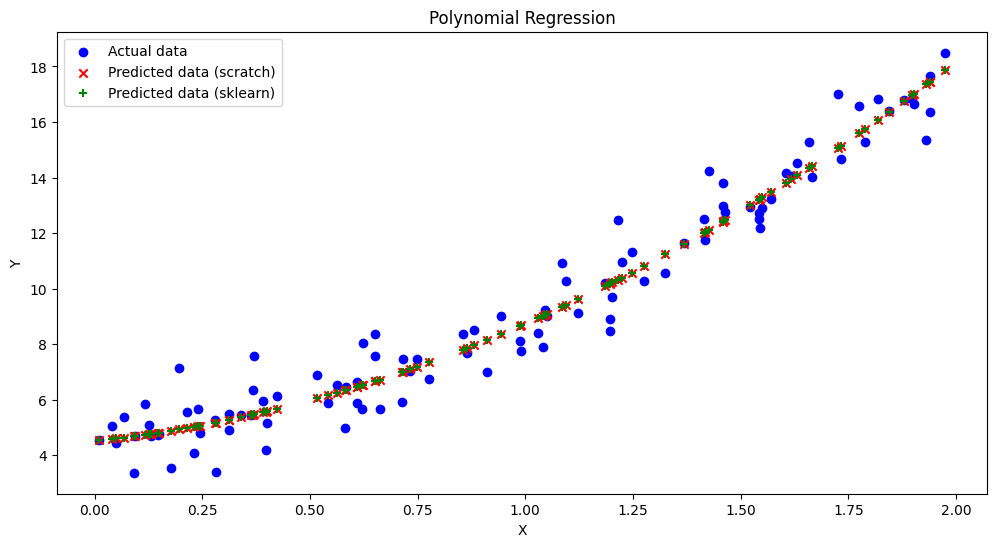

In [ ]:
plt.figure(figsize=(12, 6))

plt.scatter(X, y, color='blue', label='Actual data')
plt.scatter(X, y_pred_plot_scratch, color='red', label='Predicted data (scratch)', marker='x')
plt.scatter(X, y_predicted_plot, color='green', label='Predicted data (sklearn)', marker='+')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Polynomial Regression')
plt.legend()
plt.show()